# TP4 — Simulación de Gimnasio
## Ocupación de Máquinas en Horario Pico — con Credencial Premium
### Metodología: Evento a Evento (EaE) | Sistema M/G/c/K con Cola de Prioridades

---

### ¿De qué trata este modelo?

Simulamos el **horario pico de un gimnasio** (lunes a viernes, 18:00–21:00 hs).  
Los socios llegan, van a una de tres áreas, usan una máquina y se van.

Se incorpora una **credencial Premium**: socios que pagan una membresía especial  
y tienen **prioridad de acceso** sobre los socios regulares. Esto añade complejidad  
al sistema: ahora cada área tiene **dos colas independientes** con una política  
de atención que privilegia siempre a los Premiums.

---

### Las 3 áreas del gimnasio

| Área | Qué incluye | % de socios |
|---|---|---|
| **Cardio** | Cintas, bicicletas fijas, elípticas | 55% |
| **Musculación** | Máquinas de fuerza, pesas libres | 35% |
| **Funcional** | Área de circuito / crossfit | 10% |

---

### Sistema de Cola con Prioridades — Credencial Premium

| Casos a evaluar | Gimnasio |
|---|---|
| Alta prioridad  | Socio **Premium** |
| Baja prioridad | Socio **Regular** |
| Derivación | Rechazo (no puede entrar) |

**Reglas de prioridad:**
1. Si hay máquina libre → entra cualquier socio que llegue (Premium o Regular) sin esperar
2. Si no hay máquina libre y llega un **Premium** → espera en la cola Premium (máx. 3)
3. Si no hay máquina libre y llega un **Regular** → espera en la cola Regular (máx. 5)
4. Al liberarse una máquina → **SIEMPRE entra primero** el primer Premium en espera
5. Solo si no hay Premiums esperando → entra el primer Regular
6. Si la cola Premium está llena → el socio Premium es **rechazado** (derivado)
7. Si la cola Regular está llena → el socio Regular es **rechazado**

---

### Los 4 escenarios que comparamos

| Escenario | Cardio | Musculación | Funcional | Prioridad | Mejora |
|---|---|---|---|---|---|
| **No Eficiente** | 5 | 6 | 2 | Sin Premium | Ninguna |
| **Real** | 9 | 10 | 4 | Sin Premium | Ninguna |
| **Real + Premium** | 9 | 10 | 4 | **Con Premium (25%)** | Solo prioridad |
| **Eficiente + Premium** | 9 | 10 | 4 | **Con Premium (25%)** | App de reservas |

---

### Conexión con el Análisis Previo (EaE)

| Concepto del análisis previo | En el código |
|---|---|
| Variables de **Datos** (IA, TA_C, TA_M, TA_F) | `TASA_LLEGADA_...`, `TIEMPO_USO_POR_AREA` |
| Variables de **Control** (N_C, N_M, N_F) | `equipos_por_area` en cada escenario |
| Variables de **Estado** (NS_C, NS_M, NS_F) | `maquinas_ocupadas`, `cola_premium`, `cola_regular` |
| Variables de **Resultado** | columnas del DataFrame de resultados |
| **Eventos**: LLEGADA, SALIDA_C/M/F | strings `'llegada'` y `'salida'` en el heap |
| **TEF**: TPLL, TPS_C, TPS_M, TPS_F | el `heap` (cola de prioridad por tiempo) |


## Celda 1 — Importaciones

In [1]:
# ================================================================
# IMPORTACIONES DE LIBRERÍAS
# ================================================================
# numpy    → generación de números aleatorios y cálculos numéricos
# pandas   → tablas de datos (DataFrames) para guardar resultados
# heapq    → implementa la TEF como una cola de prioridad por tiempo
#            (siempre sabe cuál es el próximo evento más cercano)
# scipy    → pruebas estadísticas (Kolmogorov-Smirnov)
# matplotlib → gráficos de resultados
# ================================================================
import numpy as np
import pandas as pd
import heapq
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


## Celda 2 — Parámetros del sistema (Variables del Análisis Previo)

In [2]:
# ================================================================
# SEMILLA DE ALEATORIEDAD
# Fijar una semilla garantiza que los resultados sean reproducibles:
# si ejecutas el codigo dos veces, obtienes exactamente los mismos
# numeros aleatorios. Fundamental para comparar escenarios.
# ================================================================
SEMILLA_BASE = 42

# ================================================================
# AREAS DEL GIMNASIO
# 3 subsistemas INDEPENDIENTES — cada uno tiene su propia cola.
# ================================================================
AREAS = ['Cardio', 'Musculacion', 'Funcional']

# ================================================================
# FUNCION DE DENSIDAD DE PROBABILIDAD DEL IA
# (Intervalo entre Arribos — variable de DATO del analisis previo)
#
# ¿Por que Exponencial?
#   - Los socios llegan de forma independiente entre si.
#   - No hay "memoria": que haya llegado alguien hace 1 min no
#     cambia la probabilidad de que llegue alguien ahora.
#   - Esto es exactamente el proceso de Poisson, cuyo tiempo
#     entre eventos sigue una distribucion Exponencial.
#   - La prueba KS (celda 7) confirma el ajuste sobre el dataset.
#
# Parametros ajustados desde el dataset:
#   lambda = 0.40 socios/min  →  media = 1/lambda = 2.5 min
#
# Formula de la f.d.p.:   f(x) = lambda * e^(-lambda * x),  x >= 0
# ================================================================
FDP_INTERVALO_ENTRE_ARRIBOS = {
    'distribucion': 'Exponencial',
    'parametro':    'lambda',
    # lambda = tasa de llegada (socios por minuto)
    # media  = 1/lambda = tiempo promedio entre dos socios consecutivos
    'lambda':        0.40,           # socios/minuto
    'media_min':     2.5,            # minutos entre llegadas (= 1/lambda)
    'descripcion':   'Un socio llega cada 2.5 min en promedio (hora pico)',
    'justificacion': 'Llegadas independientes entre si — proceso de Poisson',
    'limite_min':    0.0,            # no hay limite superior fisico relevante
    'limite_max':    None,           # la exponencial no tiene cota superior
}

# ================================================================
# FUNCIONES DE DENSIDAD DE PROBABILIDAD DE LOS TA
# (Tiempos de Atención por área — variables de DATO del análisis)
#
# ¿Por que Normal?
#   - El tiempo de uso de una maquina tiene un valor tipico (media)
#     con variaciones simétricas en torno a él.
#   - Algunos socios usan la maquina menos, otros mas, pero la
#     mayoria se concentra cerca del promedio.
#   - La distribucion Normal captura exactamente ese comportamiento
#     de campana simetrica.
#   - La prueba KS (celda 7) confirma el ajuste sobre el dataset.
#
# IMPORTANTE: se trunca para eliminar valores fisicamente imposibles.
#   Minimo: 8 min — no tiene sentido menos que eso en ninguna area.
#   Maximo: 90 min — limite real en equipamiento compartido en pico.
#
# Cada area tiene sus propios parametros porque el comportamiento
# de uso es estructuralmente distinto:
#   Cardio      → sesion de calentamiento/cardio moderado (~32 min)
#   Musculacion → rutina de fuerza completa (~55 min)
#   Funcional   → circuito de entrenamiento (~45 min)
# ================================================================

FDP_TIEMPO_USO_POR_AREA = {

    'Cardio': {
        'distribucion':   'Normal truncada',
        'parametro':      '(mu, sigma)',
        'mu':             32,    # promedio de minutos en cinta/bici/eliptica
        'sigma':          8,     # variabilidad tipica entre socios
        'limite_min':     8,     # minimo fisico (calentamiento minimo)
        'limite_max':     90,    # maximo fisico (equipamiento compartido)
        'descripcion':    'Sesion de cardio: N(mu=32, sigma=8) min, truncada en [8, 90]',
        'justificacion':  'Sesiones tipicas de cardio se concentran en 25-40 min',
    },

    'Musculacion': {
        'distribucion':   'Normal truncada',
        'parametro':      '(mu, sigma)',
        'mu':             55,    # promedio de minutos en pesas/maquinas de fuerza
        'sigma':          12,    # mayor variabilidad (rutinas muy distintas)
        'limite_min':     8,
        'limite_max':     90,
        'descripcion':    'Rutina de fuerza: N(mu=55, sigma=12) min, truncada en [8, 90]',
        'justificacion':  'Rutinas de musculacion son mas largas y variables que cardio',
    },

    'Funcional': {
        'distribucion':   'Normal truncada',
        'parametro':      '(mu, sigma)',
        'mu':             45,    # promedio de minutos en area de circuito
        'sigma':          10,
        'limite_min':     8,
        'limite_max':     90,
        'descripcion':    'Circuito funcional: N(mu=45, sigma=10) min, truncada en [8, 90]',
        'justificacion':  'Circuitos funcionales de duracion intermedia entre cardio y fuerza',
    },
}

# ================================================================
# PROBABILIDAD DE AREA
# No es una f.d.p. continua sino una distribucion DISCRETA:
# cada socio elige exactamente una area con la probabilidad dada.
# Suma = 1.0 exacto.
# ================================================================
PROBABILIDAD_POR_AREA = [0.55, 0.35, 0.10]  # Cardio, Musculacion, Funcional

# ================================================================
# PARAMETROS DE LA SIMULACION
# ================================================================
DURACION_SIMULACION_MINUTOS = 180   # 3 horas pico (18:00-21:00)
CANTIDAD_REPLICAS           = 30    # replicas independientes por escenario

# ----------------------------------------------------------------
# Atajos de acceso rapido (usados en el motor de simulacion)
# Se derivan de los diccionarios de f.d.p. de arriba
# ----------------------------------------------------------------
TASA_LLEGADA_SOCIOS_POR_MINUTO = FDP_INTERVALO_ENTRE_ARRIBOS['lambda']
TIEMPO_USO_POR_AREA = {
    area: {
        'mu':    FDP_TIEMPO_USO_POR_AREA[area]['mu'],
        'sigma': FDP_TIEMPO_USO_POR_AREA[area]['sigma'],
    }
    for area in AREAS
}

# ================================================================
# IMPRIMIR RESUMEN DE LAS F.D.P. DEFINIDAS
# ================================================================
print('=' * 60)
print('  FUNCIONES DE DENSIDAD DE PROBABILIDAD DEL MODELO')
print('=' * 60)

fdp_ia = FDP_INTERVALO_ENTRE_ARRIBOS
print(f'\nIA — Intervalo entre Arribos:')
print(f'  Distribucion:   {fdp_ia["distribucion"]}')
print(f'  lambda:         {fdp_ia["lambda"]} socios/min')
print(f'  Media (1/lam):  {fdp_ia["media_min"]} min')
print(f'  Justificacion:  {fdp_ia["justificacion"]}')

print(f'\nTA — Tiempo de Uso por Area:')
for area in AREAS:
    fdp = FDP_TIEMPO_USO_POR_AREA[area]
    print(f'  {area:<14}: {fdp["distribucion"]}  mu={fdp["mu"]} min  sigma={fdp["sigma"]} min  [{fdp["limite_min"]}, {fdp["limite_max"]}]')
    print(f'               {fdp["justificacion"]}')

print(f'\nDistribucion discreta de areas: Cardio={PROBABILIDAD_POR_AREA[0]:.0%}  Musc={PROBABILIDAD_POR_AREA[1]:.0%}  Func={PROBABILIDAD_POR_AREA[2]:.0%}')
print(f'\nDuracion simulada:  {DURACION_SIMULACION_MINUTOS} min  ({DURACION_SIMULACION_MINUTOS/60:.0f} hs)')
print(f'Replicas:           {CANTIDAD_REPLICAS}')

# ================================================================
# PARAMETROS DE LA CREDENCIAL PREMIUM
# ================================================================
#
# ¿Qué es la credencial Premium?
#   Un socio Premium paga una membresía adicional que le garantiza
#   acceso prioritario a las máquinas durante la hora pico.
#   Nunca espera detrás de socios regulares.
#
# Parámetro de control: PROPORCION_PREMIUM
#   ¿Qué % de socios que llegan tienen credencial Premium?
#   - En escenarios "sin Premium": 0.0
#   - En escenarios "con Premium": 0.25 (25%)
#
# Tiempos de uso Premium vs Regular:
#   Los socios Premium planifican mejor su rutina (ya que pagan
#   más y usan el gimnasio con más frecuencia). Tienden a ser
#   más eficientes: usan la máquina menos tiempo por sesión.
#   Esto también beneficia la rotación del equipamiento.
# ================================================================

PROPORCION_PREMIUM = 0.25    # 25% de los socios tienen credencial Premium

# Tiempos de uso para socios REGULARES (mismos que ya teníamos)
TIEMPO_USO_REGULAR = {
    # Iguales a TIEMPO_USO_POR_AREA — sin cambios
    'Cardio':      {'mu': 32, 'sigma': 8},
    'Musculacion': {'mu': 55, 'sigma': 12},
    'Funcional':   {'mu': 45, 'sigma': 10},
}

# Tiempos de uso para socios PREMIUM
# ~15% menos de tiempo por área (planificación mejor, rutina conocida)
TIEMPO_USO_PREMIUM = {
    'Cardio':      {'mu': 27, 'sigma': 7},   # 32 - 5 min
    'Musculacion': {'mu': 45, 'sigma': 10},  # 55 - 10 min
    'Funcional':   {'mu': 38, 'sigma': 8},   # 45 - 7 min
}

# Cola máxima por tipo de socio
# El Premium tiene cola más corta: si el gimnasio está muy saturado,
# prefiere irse antes que esperar (la credencial le da el beneficio
# de acceso rápido, no el de espera larga).
MAX_COLA_PREMIUM = 3   # máx. 3 Premiums en cola por área
MAX_COLA_REGULAR = 5   # máx. 5 Regulares en cola por área

print()
print('Parametros de credencial Premium:')
print(f'  Proporcion Premium:       {PROPORCION_PREMIUM:.0%} de los socios')
print(f'  Cola max Premium:         {MAX_COLA_PREMIUM} socios por area')
print(f'  Cola max Regular:         {MAX_COLA_REGULAR} socios por area')
print()
print('Tiempos de uso Premium vs Regular (mu en minutos):')
print(f'  {"Area":<14} {"Regular mu":>12}  {"Premium mu":>12}  {"Ahorro":>8}')
for area in AREAS:
    mu_r = TIEMPO_USO_REGULAR[area]['mu']
    mu_p = TIEMPO_USO_PREMIUM[area]['mu']
    print(f'  {area:<14} {mu_r:>12}  {mu_p:>12}  {mu_r-mu_p:>8} min')


  FUNCIONES DE DENSIDAD DE PROBABILIDAD DEL MODELO

IA — Intervalo entre Arribos:
  Distribucion:   Exponencial
  lambda:         0.4 socios/min
  Media (1/lam):  2.5 min
  Justificacion:  Llegadas independientes entre si — proceso de Poisson

TA — Tiempo de Uso por Area:
  Cardio        : Normal truncada  mu=32 min  sigma=8 min  [8, 90]
               Sesiones tipicas de cardio se concentran en 25-40 min
  Musculacion   : Normal truncada  mu=55 min  sigma=12 min  [8, 90]
               Rutinas de musculacion son mas largas y variables que cardio
  Funcional     : Normal truncada  mu=45 min  sigma=10 min  [8, 90]
               Circuitos funcionales de duracion intermedia entre cardio y fuerza

Distribucion discreta de areas: Cardio=55%  Musc=35%  Func=10%

Duracion simulada:  180 min  (3 hs)
Replicas:           30

Parametros de credencial Premium:
  Proporcion Premium:       25% de los socios
  Cola max Premium:         3 socios por area
  Cola max Regular:         5 socios por area


## Celda 3 — Definicion de escenarios (Variables de Control)

In [3]:
# ================================================================
# VARIABLES DE CONTROL (exógenas controlables)
# Son las alternativas decisorias que queremos comparar.
# En el análisis previo son N_C, N_M, N_F + ahora el modo Premium.
# ================================================================
ESCENARIOS = {

    # ---------------------------------------------------------------
    # ESCENARIO 1: NO EFICIENTE
    # Pocas maquinas, sin credencial Premium. Caso base de mal desempeño.
    # ---------------------------------------------------------------
    'No Eficiente': {
        'equipos_por_area':               {'Cardio': 5, 'Musculacion': 6, 'Funcional': 2},
        'max_socios_en_cola_regular':      2,
        'max_socios_en_cola_premium':      1,
        'proporcion_premium':              0.0,   # sin credencial Premium
        'reduccion_tiempo_uso_minutos':   {'Cardio': 0, 'Musculacion': 0, 'Funcional': 0},
        'descripcion': '5 Cardio · 6 Musc · 2 Func · sin Premium',
    },

    # ---------------------------------------------------------------
    # ESCENARIO 2: REAL (situación actual, sin Premium)
    # Equipamiento actual, sin sistema de prioridades.
    # Es el escenario de referencia (baseline).
    # ---------------------------------------------------------------
    'Real': {
        'equipos_por_area':               {'Cardio': 9, 'Musculacion': 10, 'Funcional': 4},
        'max_socios_en_cola_regular':      5,
        'max_socios_en_cola_premium':      3,
        'proporcion_premium':              0.0,   # sin credencial Premium
        'reduccion_tiempo_uso_minutos':   {'Cardio': 0, 'Musculacion': 0, 'Funcional': 0},
        'descripcion': '9 Cardio · 10 Musc · 4 Func · sin Premium',
    },

    # ---------------------------------------------------------------
    # ESCENARIO 3: REAL + CREDENCIAL PREMIUM
    # Mismo equipamiento que Real, pero con sistema de prioridades.
    # El 25% de los socios tienen credencial Premium y acceden
    # primero a las maquinas cuando hay espera.
    # Permite evaluar el IMPACTO PURO de la prioridad.
    # ---------------------------------------------------------------
    'Real + Premium': {
        'equipos_por_area':               {'Cardio': 9, 'Musculacion': 10, 'Funcional': 4},
        'max_socios_en_cola_regular':      5,
        'max_socios_en_cola_premium':      MAX_COLA_PREMIUM,
        'proporcion_premium':              PROPORCION_PREMIUM,   # 25% Premium
        'reduccion_tiempo_uso_minutos':   {'Cardio': 0, 'Musculacion': 0, 'Funcional': 0},
        'descripcion': '9 Cardio · 10 Musc · 4 Func · 25% Premium sin app',
    },

    # ---------------------------------------------------------------
    # ESCENARIO 4: EFICIENTE + CREDENCIAL PREMIUM
    # Mismo equipamiento + Premium + app de reservas.
    # La app reduce el tiempo de uso (mejora operativa).
    # Mejor caso posible con la infraestructura actual.
    # ---------------------------------------------------------------
    
    'Eficiente + Premium': {
        'equipos_por_area':               {'Cardio': 9, 'Musculacion': 10, 'Funcional': 4},
        'max_socios_en_cola_regular':      5,
        'max_socios_en_cola_premium':      MAX_COLA_PREMIUM,
        'proporcion_premium':              PROPORCION_PREMIUM,   # 25% Premium
        # La app reduce el tiempo de uso (aplica a ambos tipos de socio)
        'reduccion_tiempo_uso_minutos':   {'Cardio': 5, 'Musculacion': 12, 'Funcional': 8},
        'descripcion': '9 Cardio · 10 Musc · 4 Func · 25% Premium + app',
    },
}

print('Escenarios definidos:')
for nombre, config in ESCENARIOS.items():
    eq    = config['equipos_por_area']
    prem  = config['proporcion_premium']
    red   = config['reduccion_tiempo_uso_minutos']
    print(f'  {nombre:<22}: C={eq["Cardio"]} M={eq["Musculacion"]} F={eq["Funcional"]}  '
          f'Premium={prem:.0%}  reduccion={list(red.values())}')


Escenarios definidos:
  No Eficiente          : C=5 M=6 F=2  Premium=0%  reduccion=[0, 0, 0]
  Real                  : C=9 M=10 F=4  Premium=0%  reduccion=[0, 0, 0]
  Real + Premium        : C=9 M=10 F=4  Premium=25%  reduccion=[0, 0, 0]
  Eficiente + Premium   : C=9 M=10 F=4  Premium=25%  reduccion=[5, 12, 8]


## Celda 4b — Visualización de las f.d.p. definidas

Antes de generar el dataset, graficamos las distribuciones de probabilidad para verificar visualmente que tienen forma y rango razonables.

- **IA**: curva exponencial con cola larga hacia la derecha — la mayoría de los socios llega con intervalos cortos, pero ocasionalmente hay gaps más largos.
- **TA por área**: campanas de Gauss truncadas — cada área tiene su propio centro y ancho, y ninguna genera valores menores a 8 ni mayores a 90 minutos.

Estos gráficos son la **representación visual de las f.d.p.** antes de que el simulador las use para samplear valores aleatorios.

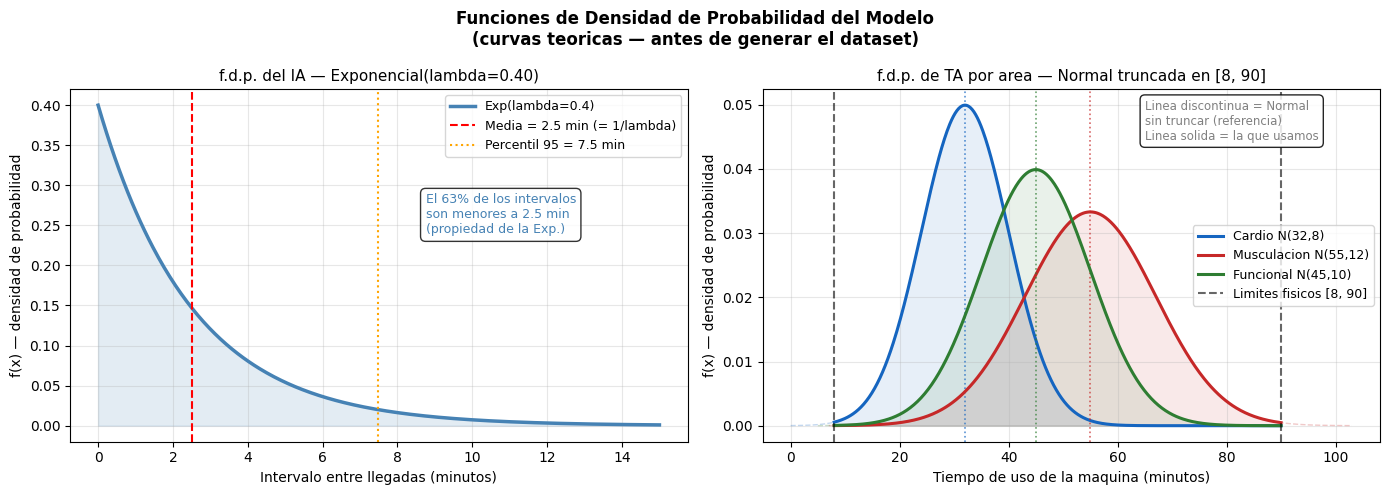

Graficos de f.d.p. guardados en fdp_definidas.png


In [4]:
# ================================================================
# VISUALIZACION DE LAS F.D.P. ANTES DE GENERAR EL DATASET
#
# Esto muestra la "forma teorica" de cada distribucion.
# Es decir: el molde con el que vamos a generar los datos.
# Cuando despues generemos el dataset, los histogramas deben
# parecerse a estas curvas (con ruido aleatorio normal).
# ================================================================

from scipy import stats as scipy_stats

COLORES_AREA = {'Cardio': '#1565C0', 'Musculacion': '#C62828', 'Funcional': '#2E7D32'}

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Funciones de Densidad de Probabilidad del Modelo\n'
    '(curvas teoricas — antes de generar el dataset)',
    fontsize=12, fontweight='bold'
)

# ----------------------------------------------------------------
# GRAFICO 1: f.d.p. del IA — Distribucion Exponencial
#
# f(x) = lambda * e^(-lambda * x)   para x >= 0
#
# La curva empieza alta (muchas llegadas con intervalo corto)
# y cae exponencialmente (pocos intervalos muy largos).
# El area bajo la curva siempre vale 1.
# ----------------------------------------------------------------
ax = ejes[0]

lam = FDP_INTERVALO_ENTRE_ARRIBOS['lambda']    # = 0.40 socios/min
media_tte = FDP_INTERVALO_ENTRE_ARRIBOS['media_min']   # = 2.5 min

# Rango de x donde graficar: de 0 a 5 veces la media (cubre el 99%)
x_tte = np.linspace(0, media_tte * 6, 400)

# Calcular la densidad de probabilidad para cada x
# scipy_stats.expon.pdf(x, scale=1/lambda) = lambda * exp(-lambda * x)
densidad_tte = scipy_stats.expon.pdf(x_tte, scale=1.0/lam)

ax.plot(x_tte, densidad_tte, color='steelblue', lw=2.5, label=f'Exp(lambda={lam})')
ax.fill_between(x_tte, 0, densidad_tte, alpha=0.15, color='steelblue')

# Marcar la media con una linea vertical
ax.axvline(media_tte, color='red', linestyle='--', lw=1.5,
           label=f'Media = {media_tte} min (= 1/lambda)')

# Marcar el percentil 95 (hasta donde llega el 95% de los intervalos)
percentil_95_tte = scipy_stats.expon.ppf(0.95, scale=1.0/lam)
ax.axvline(percentil_95_tte, color='orange', linestyle=':', lw=1.5,
           label=f'Percentil 95 = {percentil_95_tte:.1f} min')

ax.set_title('f.d.p. del IA — Exponencial(lambda=0.40)', fontsize=11)
ax.set_xlabel('Intervalo entre llegadas (minutos)')
ax.set_ylabel('f(x) — densidad de probabilidad')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Anotacion explicativa
ax.text(
    media_tte * 3.5, densidad_tte.max() * 0.6,
    f'El 63% de los intervalos\nson menores a {media_tte} min\n(propiedad de la Exp.)',
    fontsize=9, color='steelblue',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8)
)

# ----------------------------------------------------------------
# GRAFICO 2: f.d.p. de cada TA — Normal truncada por area
#
# f(x) = (1/sigma) * phi((x-mu)/sigma) / (Phi(b) - Phi(a))
# donde phi = f.d.p. normal estandar, Phi = CDF normal estandar
# a = (limite_min - mu)/sigma,  b = (limite_max - mu)/sigma
#
# Se ve como una campana de Gauss, pero cortada en los bordes:
# la zona gris representa los valores que la truncacion elimina.
# ----------------------------------------------------------------
ax = ejes[1]

for area, color in COLORES_AREA.items():
    fdp = FDP_TIEMPO_USO_POR_AREA[area]
    mu         = fdp['mu']
    sigma      = fdp['sigma']
    lim_min    = fdp['limite_min']
    lim_max    = fdp['limite_max']

    # Rango extendido (para mostrar la zona truncada)
    x_ext = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    # Rango valido (dentro de los limites fisicos)
    x_val = np.linspace(lim_min, lim_max, 500)

    # Densidad de la Normal sin truncar (para mostrar la forma completa)
    densidad_normal_completa = scipy_stats.norm.pdf(x_ext, mu, sigma)

    # Densidad de la Normal truncada (la que realmente usamos)
    # truncnorm necesita a y b en unidades de sigma:
    #   a = (limite_min - mu) / sigma
    #   b = (limite_max - mu) / sigma
    a_norm = (lim_min - mu) / sigma
    b_norm = (lim_max - mu) / sigma
    densidad_truncada = scipy_stats.truncnorm.pdf(x_val, a_norm, b_norm, loc=mu, scale=sigma)

    # Graficar la curva completa (con tono suave) y la truncada (solida)
    ax.plot(x_ext, densidad_normal_completa, color=color, lw=1, alpha=0.25, linestyle='--')
    ax.plot(x_val, densidad_truncada, color=color, lw=2.2, label=f'{area} N({mu},{sigma})')
    ax.fill_between(x_val, 0, densidad_truncada, alpha=0.10, color=color)

    # Marcar la media de cada distribucion
    ax.axvline(mu, color=color, linestyle=':', lw=1.2, alpha=0.7)

# Marcar los limites de truncacion con lineas verticales
ax.axvline(8,  color='black', linestyle='--', lw=1.5, alpha=0.6, label='Limites fisicos [8, 90]')
ax.axvline(90, color='black', linestyle='--', lw=1.5, alpha=0.6)

ax.set_title('f.d.p. de TA por area — Normal truncada en [8, 90]', fontsize=11)
ax.set_xlabel('Tiempo de uso de la maquina (minutos)')
ax.set_ylabel('f(x) — densidad de probabilidad')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Anotacion sobre la truncacion
ax.text(
    65, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 0.03,
    'Linea discontinua = Normal\nsin truncar (referencia)\nLinea solida = la que usamos',
    fontsize=8.5, color='gray',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)

plt.tight_layout()
plt.savefig('fdp_definidas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Graficos de f.d.p. guardados en fdp_definidas.png')


## Celda 4c — Generacion del dataset (usando las f.d.p. definidas)

In [5]:
# ================================================================
# GENERACION DEL DATASET
# Usamos las f.d.p. definidas en la celda anterior para samplear
# los valores de IA y TA de cada socio.
#
# Para llegar a ~1000 registros simulamos 15 dias de hora pico:
#   - 5 semanas x 5 dias = 25 dias laborales (lunes a viernes)
#   - Cada dia ~72 socios en promedio → ~1800 registros en 25 dias
#   - Tomamos los primeros 1000 para el dataset final
#
# Cada registro = un socio que ingreso al gimnasio durante la
# franja 18:00-21:00 de un dia de semana.
# ================================================================
from datetime import datetime, timedelta
import itertools

np.random.seed(SEMILLA_BASE)

registros_socios = []
id_socio         = 1

# Simular 5 semanas de dias laborales (lunes a viernes)
NOMBRES_DIAS = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes']
CANTIDAD_SEMANAS = 5    # 5 semanas x 5 dias = 25 jornadas → ~1800 socios

# Fecha de inicio: primera semana de enero 2024
from datetime import date
fecha_inicio = date(2024, 1, 8)   # primer lunes de enero 2024

for numero_semana in range(CANTIDAD_SEMANAS):
    for numero_dia, nombre_dia in enumerate(NOMBRES_DIAS):

        # Fecha real del dia (para tenerla en el dataset)
        fecha_dia = fecha_inicio + timedelta(weeks=numero_semana, days=numero_dia)
        hora_inicio_pico = datetime.combine(fecha_dia, datetime.min.time()).replace(hour=18)

        # Reloj local del dia, empieza en 0 (= 18:00 hs)
        tiempo_transcurrido_min = 0.0

        while tiempo_transcurrido_min < DURACION_SIMULACION_MINUTOS:

            # -------------------------------------------------------
            # SAMPLEO DEL IA — usando la f.d.p. Exponencial definida
            # IA ~ Exp(lambda=0.40)
            # np.random.exponential(scale) samplea de Exp(1/scale)
            # scale = media = 1/lambda = 2.5 min
            # -------------------------------------------------------
            intervalo_entre_llegadas_min = float(
                np.random.exponential(
                    scale = 1.0 / FDP_INTERVALO_ENTRE_ARRIBOS['lambda']
                )
            )

            tiempo_transcurrido_min += intervalo_entre_llegadas_min

            if tiempo_transcurrido_min >= DURACION_SIMULACION_MINUTOS:
                break   # se acabo el horario pico

            # -------------------------------------------------------
            # SAMPLEO DEL AREA — distribucion discreta
            # -------------------------------------------------------
            area_del_socio = np.random.choice(AREAS, p=PROBABILIDAD_POR_AREA)

            # -------------------------------------------------------
            # SAMPLEO DEL TA — usando la f.d.p. Normal truncada
            # TA ~ Normal(mu, sigma), truncada en [limite_min, limite_max]
            # np.random.normal() y luego np.clip() logran la truncacion.
            # -------------------------------------------------------
            fdp_ta           = FDP_TIEMPO_USO_POR_AREA[area_del_socio]
            tiempo_uso_maquina = float(
                np.clip(
                    np.random.normal(fdp_ta['mu'], fdp_ta['sigma']),
                    a_min = fdp_ta['limite_min'],   # 8 min
                    a_max = fdp_ta['limite_max'],   # 90 min
                )
            )

            hora_llegada = hora_inicio_pico + timedelta(minutes=tiempo_transcurrido_min)

            registros_socios.append({
                'id_socio':                    id_socio,
                'fecha':                       fecha_dia.strftime('%Y-%m-%d'),
                'dia_semana':                  nombre_dia,
                'semana':                      numero_semana + 1,
                'hora_llegada':                hora_llegada.strftime('%H:%M:%S'),
                'intervalo_entre_llegadas_min': round(intervalo_entre_llegadas_min, 3),
                'area':                        area_del_socio,
                'fdp_ia':                      FDP_INTERVALO_ENTRE_ARRIBOS['distribucion'],
                'fdp_ta':                      FDP_TIEMPO_USO_POR_AREA[area_del_socio]['distribucion'],
                'tiempo_uso_maquina_min':       round(tiempo_uso_maquina, 3),
            })
            id_socio += 1

# Convertir a DataFrame
dataset_completo = pd.DataFrame(registros_socios)

# Tomar exactamente 1000 registros (para consistencia)
dataset = dataset_completo.head(1000).copy().reset_index(drop=True)
dataset['id_socio'] = range(1, len(dataset) + 1)  # renumerar desde 1

print(f'Dataset generado:')
print(f'  Jornadas simuladas:  {CANTIDAD_SEMANAS * 5} dias ({CANTIDAD_SEMANAS} semanas x 5 dias)')
print(f'  Registros totales:   {len(dataset_completo)}')
print(f'  Registros en dataset:{len(dataset)} (primeros 1000)')
print(f'  Periodo:             {dataset["fecha"].min()} al {dataset["fecha"].max()}')
print()
print('Primeros 25 registros:')
dataset.head(25)


Dataset generado:
  Jornadas simuladas:  25 dias (5 semanas x 5 dias)
  Registros totales:   1774
  Registros en dataset:1000 (primeros 1000)
  Periodo:             2024-01-08 al 2024-01-26

Primeros 25 registros:


,id_socio,fecha,dia_semana,semana,hora_llegada,intervalo_entre_llegadas_min,area,fdp_ia,fdp_ta,tiempo_uso_maquina_min
0,1,2024-01-08,Lunes,1,18:01:10,1.173,Funcional,Exponencial,Normal truncada,51.477
1,2,2024-01-08,Lunes,1,18:01:35,0.424,Cardio,Exponencial,Normal truncada,44.184
2,3,2024-01-08,Lunes,1,18:01:44,0.150,Musculacion,Exponencial,Normal truncada,73.951
3,4,2024-01-08,Lunes,1,18:01:47,0.052,Funcional,Exponencial,Normal truncada,52.674
4,5,2024-01-08,Lunes,1,18:06:15,4.466,Cardio,Exponencial,Normal truncada,28.293
5,6,2024-01-08,Lunes,1,18:07:10,0.907,Cardio,Exponencial,Normal truncada,28.274
6,7,2024-01-08,Lunes,1,18:08:35,1.414,Cardio,Exponencial,Normal truncada,23.897
7,8,2024-01-08,Lunes,1,18:09:26,0.864,Cardio,Exponencial,Normal truncada,34.514
8,9,2024-01-08,Lunes,1,18:10:58,1.522,Musculacion,Exponencial,Normal truncada,55.810
9,10,2024-01-08,Lunes,1,18:13:12,2.244,Cardio,Exponencial,Normal truncada,20.602


## Celda 5 — Depuracion y validacion del dataset

In [6]:
# ================================================================
# DEPURACION DEL DATASET
# Antes de usar los datos en la simulacion, verificamos que:
# 1. No haya valores nulos
# 2. No haya valores negativos o cero en columnas numericas
# 3. Los rangos sean fisicamente realistas
# 4. La distribucion entre areas sea la esperada
# 5. Las estadisticas por area sean consistentes con el modelo
# 6. Las horas de llegada caigan dentro del horario pico
# ================================================================

print('=' * 55)
print('  VERIFICACION DE CALIDAD DEL DATASET')
print('=' * 55)

# --------------------------------------------------
# 1. Valores nulos
# Un valor nulo (NaN) en una columna numerica romperia
# los calculos estadisticos de la simulacion.
# --------------------------------------------------
cantidad_nulos_por_columna = dataset.isnull().sum()
print(f'\n1. Valores nulos por columna:')
for col, n in cantidad_nulos_por_columna.items():
    print(f'   {col:<35}: {n}')
assert cantidad_nulos_por_columna.sum() == 0, 'ERROR: hay valores nulos'
print('   OK — sin valores nulos')

# --------------------------------------------------
# 2. Valores negativos o cero en columnas numericas
# Un TTE negativo o un tiempo de uso de 0 no tienen
# sentido fisico en este sistema.
# --------------------------------------------------
negativos_tte = (dataset['intervalo_entre_llegadas_min'] <= 0).sum()
negativos_uso = (dataset['tiempo_uso_maquina_min'] <= 0).sum()
print(f'\n2. Valores negativos o cero:')
print(f'   Intervalos entre llegadas <= 0: {negativos_tte}')
print(f'   Tiempos de uso <= 0:            {negativos_uso}')
assert negativos_tte == 0 and negativos_uso == 0, 'ERROR: hay valores no fisicos'
print('   OK — todos los valores son positivos')

# --------------------------------------------------
# 3. Rangos realistas
# Verificamos que los valores extremos tengan sentido.
# --------------------------------------------------
tte_min   = dataset['intervalo_entre_llegadas_min'].min()
tte_max   = dataset['intervalo_entre_llegadas_min'].max()
tte_media = dataset['intervalo_entre_llegadas_min'].mean()
uso_min   = dataset['tiempo_uso_maquina_min'].min()
uso_max   = dataset['tiempo_uso_maquina_min'].max()

print(f'\n3. Rangos de valores:')
print(f'   TTE  → min={tte_min:.2f}  media={tte_media:.2f}  max={tte_max:.2f} min  (esperado: media~2.5)')
print(f'   Uso  → min={uso_min:.2f}  max={uso_max:.2f} min  (esperado: 8 a 90)')

assert abs(tte_media - 2.5) < 1.0, f'ERROR: media TTE ({tte_media:.2f}) muy diferente del esperado (2.5)'
assert uso_min >= 8,  f'ERROR: tiempo de uso minimo ({uso_min:.1f}) por debajo del limite fisico (8 min)'
assert uso_max <= 90, f'ERROR: tiempo de uso maximo ({uso_max:.1f}) supera el limite (90 min)'
print('   OK — rangos dentro de lo esperado')

# --------------------------------------------------
# 4. Distribucion de socios por area
# Esperamos ~55% Cardio, ~35% Musculacion, ~10% Funcional.
# Toleramos hasta 5% de desviacion (muestreo aleatorio).
# --------------------------------------------------
proporcion_por_area = dataset['area'].value_counts(normalize=True).round(3)
probabilidades_esperadas = dict(zip(AREAS, PROBABILIDAD_POR_AREA))
print(f'\n4. Distribucion de socios por area:')
print(f'   {"Area":<14} {"Observado":>10}  {"Esperado":>9}  {"Diferencia":>11}')
for area in AREAS:
    obs = proporcion_por_area.get(area, 0)
    esp = probabilidades_esperadas[area]
    dif = abs(obs - esp)
    estado = 'OK' if dif < 0.05 else 'REVISAR'
    print(f'   {area:<14} {obs:>10.1%}  {esp:>9.1%}  {dif:>11.1%}  {estado}')

# --------------------------------------------------
# 5. Estadisticas de uso por area
# La media observada debe estar cerca de la teorica (mu).
# --------------------------------------------------
print(f'\n5. Estadisticas de tiempo de uso por area:')
print(f'   {"Area":<14} {"Media obs":>10}  {"Media esp":>10}  {"Sigma obs":>10}  {"Sigma esp":>10}')
for area in AREAS:
    datos_area = dataset[dataset['area'] == area]['tiempo_uso_maquina_min']
    media_obs  = datos_area.mean()
    sigma_obs  = datos_area.std()
    media_esp  = TIEMPO_USO_POR_AREA[area]['mu']
    sigma_esp  = TIEMPO_USO_POR_AREA[area]['sigma']
    diferencia = abs(media_obs - media_esp)
    estado     = 'OK' if diferencia < 5 else 'REVISAR'
    print(f'   {area:<14} {media_obs:>10.2f}  {media_esp:>10.1f}  {sigma_obs:>10.2f}  {sigma_esp:>10.1f}  {estado}')

# --------------------------------------------------
# 6. Consistencia temporal
# Las horas deben estar entre 18:00 y 21:00 hs.
# --------------------------------------------------
horas_validas = dataset['hora_llegada'].apply(
    lambda h: '18:00:00' <= h <= '21:00:00'
).all()
print(f'\n6. Todas las llegadas dentro del horario pico (18:00-21:00): {"OK" if horas_validas else "REVISAR"}')

print('\n' + '=' * 55)
print('  DATASET APROBADO — datos limpios y consistentes')
print('=' * 55)

  VERIFICACION DE CALIDAD DEL DATASET

1. Valores nulos por columna:
   id_socio                           : 0
   fecha                              : 0
   dia_semana                         : 0
   semana                             : 0
   hora_llegada                       : 0
   intervalo_entre_llegadas_min       : 0
   area                               : 0
   fdp_ia                             : 0
   fdp_ta                             : 0
   tiempo_uso_maquina_min             : 0
   OK — sin valores nulos

2. Valores negativos o cero:
   Intervalos entre llegadas <= 0: 0
   Tiempos de uso <= 0:            0
   OK — todos los valores son positivos

3. Rangos de valores:
   TTE  → min=0.00  media=2.64  max=18.60 min  (esperado: media~2.5)
   Uso  → min=10.72  max=90.00 min  (esperado: 8 a 90)
   OK — rangos dentro de lo esperado

4. Distribucion de socios por area:
   Area            Observado   Esperado   Diferencia
   Cardio              57.5%      55.0%         2.5%  OK
   Muscula

## Celda 6 — Analisis exploratorio visual

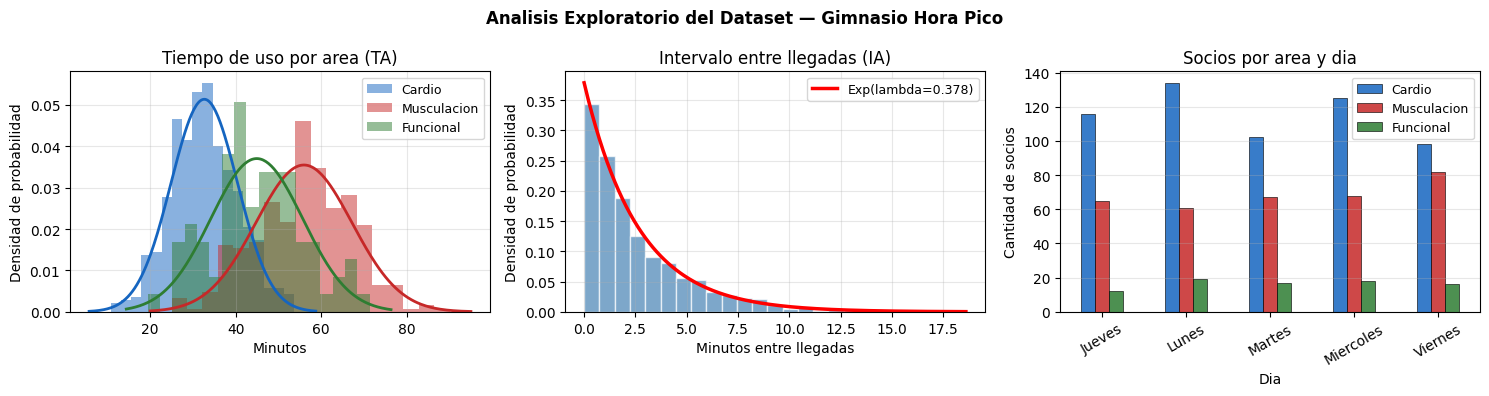

In [7]:
# ================================================================
# ANALISIS EXPLORATORIO VISUAL
# Antes de simular, siempre miramos los datos.
# Asi nos aseguramos de que tienen sentido antes de usarlos.
# ================================================================

COLORES_AREA = {'Cardio': '#1565C0', 'Musculacion': '#C62828', 'Funcional': '#2E7D32'}

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analisis Exploratorio del Dataset — Gimnasio Hora Pico', fontsize=12, fontweight='bold')

# --- Grafico 1: Distribucion del tiempo de uso por area ---
# Cada area deberia verse como una campana de Gauss (distribucion Normal)
for area, color in COLORES_AREA.items():
    datos_area  = dataset[dataset['area'] == area]['tiempo_uso_maquina_min']
    media_area  = datos_area.mean()
    desvio_area = datos_area.std()
    x_curva     = np.linspace(datos_area.min() - 5, datos_area.max() + 5, 200)

    ejes[0].hist(datos_area, bins=18, color=color, alpha=0.5, density=True, label=area)
    ejes[0].plot(x_curva, stats.norm.pdf(x_curva, media_area, desvio_area), color=color, lw=2)

ejes[0].set_title('Tiempo de uso por area (TA)')
ejes[0].set_xlabel('Minutos')
ejes[0].set_ylabel('Densidad de probabilidad')
ejes[0].legend(fontsize=9)
ejes[0].grid(alpha=0.3)

# --- Grafico 2: Distribucion del intervalo entre llegadas (IA) ---
# Esperamos una curva exponencial (cola larga hacia la derecha)
tte_datos           = dataset['intervalo_entre_llegadas_min']
loc_exp, escala_exp = stats.expon.fit(tte_datos, floc=0)
x_exp               = np.linspace(0, tte_datos.max(), 200)

ejes[1].hist(tte_datos, bins=25, color='steelblue', alpha=0.7, density=True, edgecolor='white')
ejes[1].plot(x_exp, stats.expon.pdf(x_exp, loc_exp, escala_exp),
             'r-', lw=2.5, label=f'Exp(lambda={1/escala_exp:.3f})')
ejes[1].set_title('Intervalo entre llegadas (IA)')
ejes[1].set_xlabel('Minutos entre llegadas')
ejes[1].set_ylabel('Densidad de probabilidad')
ejes[1].legend(fontsize=9)
ejes[1].grid(alpha=0.3)

# --- Grafico 3: Cantidad de socios por area y dia ---
# Verificamos que la distribucion sea estable entre dias
conteos_dia_area = dataset.groupby(['dia_semana', 'area']).size().unstack(fill_value=0)
conteos_dia_area[AREAS].plot(
    kind='bar', ax=ejes[2],
    color=[COLORES_AREA[a] for a in AREAS],
    alpha=0.85, edgecolor='black', linewidth=0.5
)
ejes[2].set_title('Socios por area y dia')
ejes[2].set_xlabel('Dia')
ejes[2].set_ylabel('Cantidad de socios')
ejes[2].tick_params(axis='x', rotation=30)
ejes[2].legend(fontsize=9)
ejes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_exploratorio.png', dpi=120, bbox_inches='tight')
plt.show()

## Celda 7 — Prueba de bondad de ajuste (Kolmogorov-Smirnov)

In [8]:
# ================================================================
# PRUEBA KS (Kolmogorov-Smirnov)
# Verifica formalmente que las distribuciones elegidas
# se ajustan bien a los datos observados.
#
# H0: los datos siguen la distribucion propuesta
# Si p-valor > 0.05 -> NO rechazamos H0 -> la distribucion ajusta
# Si p-valor < 0.05 -> rechazamos H0 -> hay que buscar otra
# ================================================================

print('=' * 65)
print('  PRUEBA DE BONDAD DE AJUSTE — Kolmogorov-Smirnov (alpha=0.05)')
print('=' * 65)

# --- Probar que IA sigue una distribucion Exponencial ---
tte_datos                        = dataset['intervalo_entre_llegadas_min'].values
loc_ajustado, escala_ajustada    = stats.expon.fit(tte_datos, floc=0)
lambda_estimado                  = 1.0 / escala_ajustada
estadistico_ks, p_valor          = stats.kstest(tte_datos, 'expon', args=(loc_ajustado, escala_ajustada))

print(f'\nIA (intervalo entre llegadas):')
print(f'  Distribucion ajustada: Exponencial(lambda={lambda_estimado:.4f})')
print(f'  Media ajustada:        {escala_ajustada:.2f} min  (esperado: 2.5 min)')
print(f'  KS estadistico:        {estadistico_ks:.4f}')
print(f'  p-valor:               {p_valor:.4f}')
print(f'  Conclusion:            {"ACEPTA H0" if p_valor > 0.05 else "RECHAZA H0"} — '
      f'{"distribucion Exponencial ajusta bien" if p_valor > 0.05 else "buscar otra distribucion"}')

# --- Probar que TA de cada area sigue una Normal ---
print(f'\nTiempos de uso por area (Normal):')
print(f'  {"Area":<14} {"mu obs":>8}  {"mu esp":>8}  {"sigma obs":>10}  {"sigma esp":>10}  {"p-valor":>9}  Resultado')
print(f'  {"-"*80}')

for area in AREAS:
    datos_area                = dataset[dataset['area'] == area]['tiempo_uso_maquina_min'].values
    mu_ajustado, sig_ajustado = stats.norm.fit(datos_area)
    estadistico, p_valor_area = stats.kstest(datos_area, 'norm', args=(mu_ajustado, sig_ajustado))
    mu_esperado               = TIEMPO_USO_POR_AREA[area]['mu']
    sigma_esperado            = TIEMPO_USO_POR_AREA[area]['sigma']
    resultado                 = 'ACEPTA H0' if p_valor_area > 0.05 else 'RECHAZA H0'

    print(f'  {area:<14} {mu_ajustado:>8.2f}  {mu_esperado:>8.1f}  '
          f'{sig_ajustado:>10.2f}  {sigma_esperado:>10.1f}  '
          f'{p_valor_area:>9.4f}  {resultado}')

print(f'\n  Interpretacion: p-valor > 0.05 la distribucion ajusta bien a los datos')

  PRUEBA DE BONDAD DE AJUSTE — Kolmogorov-Smirnov (alpha=0.05)

IA (intervalo entre llegadas):
  Distribucion ajustada: Exponencial(lambda=0.3785)
  Media ajustada:        2.64 min  (esperado: 2.5 min)
  KS estadistico:        0.0262
  p-valor:               0.4888
  Conclusion:            ACEPTA H0 — distribucion Exponencial ajusta bien

Tiempos de uso por area (Normal):
  Area             mu obs    mu esp   sigma obs   sigma esp    p-valor  Resultado
  --------------------------------------------------------------------------------
  Cardio            32.66      32.0        7.76         8.0     0.7930  ACEPTA H0
  Musculacion       55.95      55.0       11.23        12.0     0.3478  ACEPTA H0
  Funcional         44.93      45.0       10.71        10.0     0.9590  ACEPTA H0

  Interpretacion: p-valor > 0.05 la distribucion ajusta bien a los datos


## Celda 8 — El motor de la simulación (Metodología EaE con Cola de Prioridades)

Implementa la metodología **Evento a Evento**
con la extensión de **cola de prioridades**.

### Tabla de Eventos Independientes (T.E.I.) — con Prioridad Premium

| EVENTO | E.F. NO C. | E.F. C. | CONDICIÓN |
|---|---|---|---|
| LLEGADA Premium | LLEGADA | SALIDA (área) | maquinas_ocupadas < capacidad |
| LLEGADA Premium | LLEGADA | — (cola) | maquinas_ocupadas = cap **Y** cola_prem < MAX_PREM |
| LLEGADA Premium | LLEGADA | — (rechazado) | maquinas_ocupadas = cap **Y** cola_prem = MAX_PREM |
| LLEGADA Regular | LLEGADA | SALIDA (área) | maquinas_ocupadas < capacidad |
| LLEGADA Regular | LLEGADA | — (cola) | maquinas_ocupadas = cap **Y** cola_reg < MAX_REG |
| LLEGADA Regular | LLEGADA | — (rechazado) | maquinas_ocupadas = cap **Y** cola_reg = MAX_REG |
| SALIDA (área) | — | SALIDA (área) Premium | cola_prem ≥ 1 ← **PRIORIDAD** |
| SALIDA (área) | — | SALIDA (área) Regular | cola_prem = 0 **Y** cola_reg ≥ 1 |

**Regla clave de prioridad (fila SALIDA):**
Al liberar una máquina, el E.F.C. siempre verifica primero la cola Premium.
Solo si esa cola está vacía se atiende al primer Regular.
Esto es la implementación directa del sistema de prioridades.

### TEF actualizada:
`TPLL, TPS_C, TPS_M, TPS_F`
(igual que antes — la prioridad es una regla de estado, no un evento nuevo)


In [9]:
def simular_una_jornada(
    equipos_por_area,              # N_C, N_M, N_F  — variables de CONTROL
    probabilidad_por_area,         # probabilidad de ir a cada area
    max_cola_regular,              # tamano maximo de cola de socios regulares
    max_cola_premium,              # tamano maximo de cola de socios Premium
    proporcion_premium,            # fraccion de socios con credencial Premium (0.0 a 1.0)
    tiempo_uso_regular,            # TA por area para socios regulares — variable de DATOS
    tiempo_uso_premium,            # TA por area para socios Premium — variable de DATOS
    tasa_llegada,                  # lambda del IA — variable de DATOS
    duracion_simulacion,           # tiempo total a simular (minutos)
    semilla_aleatoria              # semilla para reproducibilidad
):
    """
    Simula UNA jornada de hora pico con sistema de cola de prioridades.

    LÓGICA DE PRIORIDAD (basada en el ejercicio Doctor House):
      - Socio Premium = alta prioridad (como el Dr. House)
      - Socio Regular = baja prioridad (como los médicos ayudantes)
      - Al liberarse una máquina: SIEMPRE atiende primero a un Premium en espera
      - Si cola Premium llena → Premium rechazado (derivado, como en Doctor House)
      - Dos colas independientes por área: una Premium y una Regular

    Variables de estado del modelo:
      maquinas_ocupadas[area] = NS — socios usando maquina en este instante
      cola_premium[area]      = socios Premium esperando (ANTES que los regulares)
      cola_regular[area]      = socios Regular esperando (DESPUES de los Premiums)
    """

    # ----------------------------------------------------------------
    # INICIALIZACION DEL GENERADOR ALEATORIO
    # ----------------------------------------------------------------
    generador_aleatorio = np.random.default_rng(semilla_aleatoria)

    # ----------------------------------------------------------------
    # VECTOR DE ESTADO — se actualiza con cada evento
    # maquinas_ocupadas : cuantas maquinas estan en uso en cada area
    # cola_premium / cola_regular : socios esperando por tipo
    # ----------------------------------------------------------------
    maquinas_ocupadas  = {area: 0 for area in AREAS}
    cola_premium       = {area: 0 for area in AREAS}   # cola de alta prioridad
    cola_regular       = {area: 0 for area in AREAS}   # cola de baja prioridad
    cola_max_premium   = {area: 0 for area in AREAS}
    cola_max_regular   = {area: 0 for area in AREAS}

    # ----------------------------------------------------------------
    # CONTADORES DE RESULTADO — separados por tipo de socio
    # ----------------------------------------------------------------
    llegadas_premium   = {area: 0 for area in AREAS}
    llegadas_regular   = {area: 0 for area in AREAS}
    atendidos_premium  = {area: 0 for area in AREAS}
    atendidos_regular  = {area: 0 for area in AREAS}
    rechazados_premium = {area: 0 for area in AREAS}  # cola Premium llena → rechazado
    rechazados_regular = {area: 0 for area in AREAS}  # cola Regular llena → rechazado
    tiempos_espera_premium = {area: [] for area in AREAS}
    tiempos_espera_regular = {area: [] for area in AREAS}

    # ----------------------------------------------------------------
    # ACUMULADOR DE UTILIZACION
    # ----------------------------------------------------------------
    socios_minuto_acumulado  = {area: 0.0 for area in AREAS}
    tiempo_del_ultimo_evento = {area: 0.0 for area in AREAS}

    # ----------------------------------------------------------------
    # TABLA DE EVENTOS FUTUROS (TEF) — min-heap
    # Cada evento: (tiempo, tipo_evento, id, area, tipo_socio)
    # tipo_socio = 'premium' | 'regular' | None (para LLEGADA)
    # ----------------------------------------------------------------
    tef       = []
    id_evento = 0

    # Primera llegada
    t0 = float(generador_aleatorio.exponential(1.0 / tasa_llegada))
    heapq.heappush(tef, (t0, 'llegada', id_evento, None, None))
    id_evento += 1

    # ================================================================
    # CICLO PRINCIPAL — Metodología Evento a Evento
    # ================================================================
    while tef:

        # PASO 1: Tomar el próximo evento de la TEF (menor tiempo)
        t, tipo_ev, _, area_ev, tipo_socio_ev = heapq.heappop(tef)

        # PASO 2: ¿Terminó la jornada?
        if t > duracion_simulacion:
            for area in AREAS:
                socios_minuto_acumulado[area] += (
                    maquinas_ocupadas[area] * (duracion_simulacion - tiempo_del_ultimo_evento[area])
                )
            break

        # ================================================================
        # EVENTO: LLEGADA
        # ================================================================
        if tipo_ev == 'llegada':

            # Actualizar el acumulador para TODAS las áreas
            for area in AREAS:
                dt = t - tiempo_del_ultimo_evento[area]
                socios_minuto_acumulado[area]    += maquinas_ocupadas[area] * dt
                tiempo_del_ultimo_evento[area]    = t

            # EF.NC: programar la próxima LLEGADA
            nuevo_tte = float(generador_aleatorio.exponential(1.0 / tasa_llegada))
            heapq.heappush(tef, (t + nuevo_tte, 'llegada', id_evento, None, None))
            id_evento += 1

            # Determinar área y tipo del socio
            area_del_socio = generador_aleatorio.choice(AREAS, p=probabilidad_por_area)
            es_premium     = (generador_aleatorio.random() < proporcion_premium)
            tipo_socio     = 'premium' if es_premium else 'regular'

            cap = equipos_por_area[area_del_socio]

            # Seleccionar parámetros de tiempo de uso según tipo
            if es_premium:
                uso_p = tiempo_uso_premium[area_del_socio]
                llegadas_premium[area_del_socio] += 1
            else:
                uso_p = tiempo_uso_regular[area_del_socio]
                llegadas_regular[area_del_socio] += 1

            # ── DECISIÓN DE ACCESO ───────────────────────────────────────────
            # (Aquí se implementa la lógica de prioridad)

            if maquinas_ocupadas[area_del_socio] < cap:
                # CASO 1: Hay máquina libre → entra CUALQUIER socio directamente
                # (la prioridad no importa si no hay espera)
                maquinas_ocupadas[area_del_socio] += 1
                dur = float(np.clip(generador_aleatorio.normal(uso_p['mu'], uso_p['sigma']), 8, 90))
                heapq.heappush(tef, (t + dur, 'salida', id_evento, area_del_socio, tipo_socio))
                id_evento += 1

                if es_premium:
                    atendidos_premium[area_del_socio] += 1
                    tiempos_espera_premium[area_del_socio].append(0.0)
                else:
                    atendidos_regular[area_del_socio] += 1
                    tiempos_espera_regular[area_del_socio].append(0.0)

            elif es_premium:
                # CASO 2: No hay máquina libre + es Premium
                # El Premium tiene su propia cola (más prioritaria).
                # Si la cola Premium está llena → RECHAZADO (como en Doctor House:
                # el caso de alta complejidad se deriva si House no está libre)
                if cola_premium[area_del_socio] < max_cola_premium:
                    cola_premium[area_del_socio] += 1
                    cola_max_premium[area_del_socio] = max(
                        cola_max_premium[area_del_socio], cola_premium[area_del_socio]
                    )
                    # Espera estimada: va primero que todos los regulares
                    espera_est = cola_premium[area_del_socio] * (uso_p['mu'] / cap)
                    tiempos_espera_premium[area_del_socio].append(espera_est)
                else:
                    # Cola Premium llena → Premium rechazado (se va a otro gimnasio)
                    rechazados_premium[area_del_socio] += 1

            else:
                # CASO 3: No hay máquina libre + es Regular
                # El Regular va detrás de TODOS los Premiums en espera.
                # Si la cola Regular también está llena → RECHAZADO
                if cola_regular[area_del_socio] < max_cola_regular:
                    cola_regular[area_del_socio] += 1
                    cola_max_regular[area_del_socio] = max(
                        cola_max_regular[area_del_socio], cola_regular[area_del_socio]
                    )
                    # Espera estimada: espera todos los Premiums + su lugar en cola regular
                    socios_antes = cola_premium[area_del_socio] + cola_regular[area_del_socio]
                    espera_est   = socios_antes * (uso_p['mu'] / cap)
                    tiempos_espera_regular[area_del_socio].append(espera_est)
                else:
                    # Cola Regular llena → Regular rechazado
                    rechazados_regular[area_del_socio] += 1

        # ================================================================
        # EVENTO: SALIDA
        # ================================================================
        else:
            area = area_ev

            # Actualizar acumulador de esta área específica
            dt = t - tiempo_del_ultimo_evento[area]
            socios_minuto_acumulado[area]    += maquinas_ocupadas[area] * dt
            tiempo_del_ultimo_evento[area]    = t

            # Liberar la máquina
            maquinas_ocupadas[area] = max(0, maquinas_ocupadas[area] - 1)

            # ── POLÍTICA DE PRIORIDAD AL LIBERAR ────────────────────────────
            # SIEMPRE primero el Premium, solo después el Regular.
            # (Esta es la implementación clave del sistema de prioridades)

            if cola_premium[area] > 0:
                # Hay un Premium esperando → entra ANTES que cualquier Regular
                cola_premium[area] -= 1
                maquinas_ocupadas[area] += 1
                atendidos_premium[area] += 1
                uso_p = tiempo_uso_premium[area]
                dur   = float(np.clip(
                    generador_aleatorio.normal(uso_p['mu'], uso_p['sigma']), 8, 90
                ))
                heapq.heappush(tef, (t + dur, 'salida', id_evento, area, 'premium'))
                id_evento += 1

            elif cola_regular[area] > 0:
                # No hay Premiums esperando → recién ahora entra el primer Regular
                cola_regular[area] -= 1
                maquinas_ocupadas[area] += 1
                atendidos_regular[area] += 1
                uso_p = tiempo_uso_regular[area]
                dur   = float(np.clip(
                    generador_aleatorio.normal(uso_p['mu'], uso_p['sigma']), 8, 90
                ))
                heapq.heappush(tef, (t + dur, 'salida', id_evento, area, 'regular'))
                id_evento += 1
            # Si no hay nadie en ninguna cola → la máquina queda libre

    # ================================================================
    # CALCULAR MÉTRICAS DE RESULTADO
    # ================================================================
    metricas = {}
    total_ll = total_at = total_rec_p = total_rec_r = 0

    for area in AREAS:
        cap  = equipos_por_area[area]
        util = (
            socios_minuto_acumulado[area] / (duracion_simulacion * cap) * 100
            if cap > 0 else 0
        )

        ll_p  = llegadas_premium[area];  at_p  = atendidos_premium[area];  rec_p = rechazados_premium[area]
        ll_r  = llegadas_regular[area];  at_r  = atendidos_regular[area];  rec_r = rechazados_regular[area]

        tasa_rec_p = rec_p / ll_p * 100 if ll_p > 0 else 0
        tasa_rec_r = rec_r / ll_r * 100 if ll_r > 0 else 0

        esp_p = float(np.mean(tiempos_espera_premium[area])) if tiempos_espera_premium[area] else 0.0
        esp_r = float(np.mean(tiempos_espera_regular[area])) if tiempos_espera_regular[area] else 0.0

        metricas[f'Llegadas_Premium_{area}']             = ll_p
        metricas[f'Llegadas_Regular_{area}']             = ll_r
        metricas[f'Atendidos_Premium_{area}']            = at_p
        metricas[f'Atendidos_Regular_{area}']            = at_r
        metricas[f'Rechazados_Premium_{area}']           = rec_p
        metricas[f'Rechazados_Regular_{area}']           = rec_r
        metricas[f'Tasa_Rechazo_pct_Premium_{area}']    = round(tasa_rec_p, 3)
        metricas[f'Tasa_Rechazo_pct_Regular_{area}']    = round(tasa_rec_r, 3)
        metricas[f'Utilizacion_pct_{area}']             = round(util, 2)
        metricas[f'Espera_Promedio_min_Premium_{area}'] = round(esp_p, 3)
        metricas[f'Espera_Promedio_min_Regular_{area}'] = round(esp_r, 3)
        metricas[f'Cola_Max_Premium_{area}']            = cola_max_premium[area]
        metricas[f'Cola_Max_Regular_{area}']            = cola_max_regular[area]

        total_ll    += ll_p + ll_r
        total_at    += at_p + at_r
        total_rec_p += rec_p
        total_rec_r += rec_r

    total_ll_p = sum(llegadas_premium[a] for a in AREAS)
    total_ll_r = sum(llegadas_regular[a] for a in AREAS)

    metricas['Total_Llegadas']                  = total_ll
    metricas['Total_Atendidos']                 = total_at
    metricas['Total_Rechazados_Premium']        = total_rec_p
    metricas['Total_Rechazados_Regular']        = total_rec_r
    metricas['Tasa_Rechazo_pct_Premium_Total']  = round(total_rec_p / total_ll_p * 100 if total_ll_p > 0 else 0, 3)
    metricas['Tasa_Rechazo_pct_Regular_Total']  = round(total_rec_r / total_ll_r * 100 if total_ll_r > 0 else 0, 3)
    metricas['Tasa_Rechazo_pct_Total']          = round((total_rec_p + total_rec_r) / total_ll * 100 if total_ll > 0 else 0, 3)
    return metricas


def simular_escenario(config_escenario, cantidad_replicas, semilla_base):
    """
    Corre CANTIDAD_REPLICAS jornadas para un escenario y retorna DataFrame.
    Ahora pasa los parametros Premium/Regular al motor de simulacion.
    """
    # Aplicar la reduccion de tiempo de uso del escenario (si la hay)
    red   = config_escenario['reduccion_tiempo_uso_minutos']
    prop  = config_escenario['proporcion_premium']

    uso_regular_esc = {
        area: {
            'mu':    TIEMPO_USO_REGULAR[area]['mu']    - red[area],
            'sigma': TIEMPO_USO_REGULAR[area]['sigma'],
        }
        for area in AREAS
    }
    uso_premium_esc = {
        area: {
            'mu':    TIEMPO_USO_PREMIUM[area]['mu']    - red[area],
            'sigma': TIEMPO_USO_PREMIUM[area]['sigma'],
        }
        for area in AREAS
    }

    resultados = []
    for rep in range(cantidad_replicas):
        semilla_rep = semilla_base + rep * 37
        metricas    = simular_una_jornada(
            equipos_por_area      = config_escenario['equipos_por_area'],
            probabilidad_por_area = PROBABILIDAD_POR_AREA,
            max_cola_regular      = config_escenario['max_socios_en_cola_regular'],
            max_cola_premium      = config_escenario['max_socios_en_cola_premium'],
            proporcion_premium    = prop,
            tiempo_uso_regular    = uso_regular_esc,
            tiempo_uso_premium    = uso_premium_esc,
            tasa_llegada          = TASA_LLEGADA_SOCIOS_POR_MINUTO,
            duracion_simulacion   = DURACION_SIMULACION_MINUTOS,
            semilla_aleatoria     = semilla_rep,
        )
        resultados.append(metricas)

    return pd.DataFrame(resultados)


print('Motor de simulacion con cola de prioridades definido.')
print('  simular_una_jornada()  — incluye logica Premium/Regular')
print('  simular_escenario()    — corre N replicas de un escenario')


Motor de simulacion con cola de prioridades definido.
  simular_una_jornada()  — incluye logica Premium/Regular
  simular_escenario()    — corre N replicas de un escenario


## Celda 9 — Ejecución de los 4 escenarios

In [10]:
# ================================================================
# EJECUTAR LA SIMULACION PARA CADA ESCENARIO
# ================================================================

print('=' * 65)
print('  SIMULACION EN EJECUCION...')
print(f'  {CANTIDAD_REPLICAS} replicas x {len(ESCENARIOS)} escenarios = {CANTIDAD_REPLICAS*len(ESCENARIOS)} jornadas simuladas')
print('=' * 65)

resultados_por_escenario = {}

for nombre_escenario, configuracion in ESCENARIOS.items():

    df_resultados = simular_escenario(
        config_escenario  = configuracion,
        cantidad_replicas = CANTIDAD_REPLICAS,
        semilla_base      = SEMILLA_BASE
    )
    resultados_por_escenario[nombre_escenario] = df_resultados

    n = len(df_resultados)
    print(f'\n{"-"*62}')
    print(f'  ESCENARIO: {nombre_escenario.upper()}')
    print(f'  {configuracion["descripcion"]}')
    print(f'  {"Metrica":<45}  {"Media":>8}  {"IC 95% +-":>10}')
    print(f'  {"-"*68}')

    metricas_globales = [
        'Total_Llegadas', 'Total_Atendidos',
        'Total_Rechazados_Premium', 'Total_Rechazados_Regular',
        'Tasa_Rechazo_pct_Premium_Total', 'Tasa_Rechazo_pct_Regular_Total',
        'Tasa_Rechazo_pct_Total',
    ]
    metricas_por_area = []
    for area in AREAS:
        metricas_por_area += [
            f'Utilizacion_pct_{area}',
            f'Espera_Promedio_min_Premium_{area}',
            f'Espera_Promedio_min_Regular_{area}',
        ]

    for col in metricas_globales + metricas_por_area:
        if col not in df_resultados.columns:
            continue
        media = df_resultados[col].mean()
        ic_95 = 1.96 * df_resultados[col].std() / np.sqrt(n)
        print(f'  {col:<45}  {media:>8.2f}  +-{ic_95:>8.2f}')

print(f'\nSimulacion completada.')


  SIMULACION EN EJECUCION...
  30 replicas x 4 escenarios = 120 jornadas simuladas

--------------------------------------------------------------
  ESCENARIO: NO EFICIENTE
  5 Cardio · 6 Musc · 2 Func · sin Premium
  Metrica                                           Media   IC 95% +-
  --------------------------------------------------------------------
  Total_Llegadas                                    72.23  +-    3.01
  Total_Atendidos                                   52.17  +-    1.07
  Total_Rechazados_Premium                           0.00  +-    0.00
  Total_Rechazados_Regular                          18.00  +-    2.45
  Tasa_Rechazo_pct_Premium_Total                     0.00  +-    0.00
  Tasa_Rechazo_pct_Regular_Total                    24.19  +-    2.67
  Tasa_Rechazo_pct_Total                            24.19  +-    2.67
  Utilizacion_pct_Cardio                            86.61  +-    2.40
  Espera_Promedio_min_Premium_Cardio                 0.00  +-    0.00
  Espera_Prom

## Celda 10 — Analisis de sensibilidad

In [11]:
# ================================================================
# ANALISIS DE SENSIBILIDAD
# Pregunta: si variamos la cantidad de maquinas de Musculacion,
# como cambia la tasa de rechazo?
#
# Por que Musculacion: es el area de mayor tiempo de uso (55 min)
# y tiene el 35% de los socios. Es el cuello de botella potencial.
#
# Mantenemos fijo: Cardio=9, Funcional=4
# Variamos:        Musculacion de 3 a 15 maquinas
# ================================================================

print('Ejecutando analisis de sensibilidad...')

filas_sensibilidad = []

for cantidad_maquinas_musculacion in range(3, 16):

    # Configuracion temporal con solo Musculacion variando
    config_para_sensibilidad = {
        'equipos_por_area': {
            'Cardio':      9,
            'Musculacion': cantidad_maquinas_musculacion,
            'Funcional':   4,
        },
        'max_socios_en_cola_regular':  5,
        'max_socios_en_cola_premium':  MAX_COLA_PREMIUM,
        'proporcion_premium':          0.0,
        'reduccion_tiempo_uso_minutos': {'Cardio': 0, 'Musculacion': 0, 'Funcional': 0},
        'descripcion': f'Sensibilidad: {cantidad_maquinas_musculacion} maquinas Musculacion'
    }

    # 20 replicas alcanzan para trazar la curva (no necesitamos 30 aca)
    df_sensibilidad_parcial = simular_escenario(
        config_escenario  = config_para_sensibilidad,
        cantidad_replicas = 20,
        semilla_base      = SEMILLA_BASE
    )

    filas_sensibilidad.append({
        'Maquinas_Musculacion':         cantidad_maquinas_musculacion,
        'Tasa_Rechazo_pct_Regular_Musculacion': round(df_sensibilidad_parcial['Tasa_Rechazo_pct_Regular_Musculacion'].mean(), 2),
        'Utilizacion_pct_Musculacion':  round(df_sensibilidad_parcial['Utilizacion_pct_Musculacion'].mean(), 1),
        'Tasa_Rechazo_pct_Total':       round(df_sensibilidad_parcial['Tasa_Rechazo_pct_Total'].mean(), 2),
        'Socios_Atendidos_Promedio':    round(df_sensibilidad_parcial['Total_Atendidos'].mean(), 1),
    })

df_analisis_sensibilidad = pd.DataFrame(filas_sensibilidad)

print('Resultados:')
print(df_analisis_sensibilidad.to_string(index=False))
print('\nAnalisis de sensibilidad completado')

Ejecutando analisis de sensibilidad...
Resultados:
 Maquinas_Musculacion  Tasa_Rechazo_pct_Regular_Musculacion  Utilizacion_pct_Musculacion  Tasa_Rechazo_pct_Total  Socios_Atendidos_Promedio
                    3                                 36.60                         88.1                   13.33                       57.0
                    4                                 19.11                         85.5                    6.74                       57.3
                    5                                 14.57                         81.3                    5.49                       61.0
                    6                                  6.75                         77.6                    2.74                       62.5
                    7                                  2.77                         73.0                    1.58                       65.2
                    8                                  1.16                         66.2                    0

## Celda 11 — Graficos de resultados

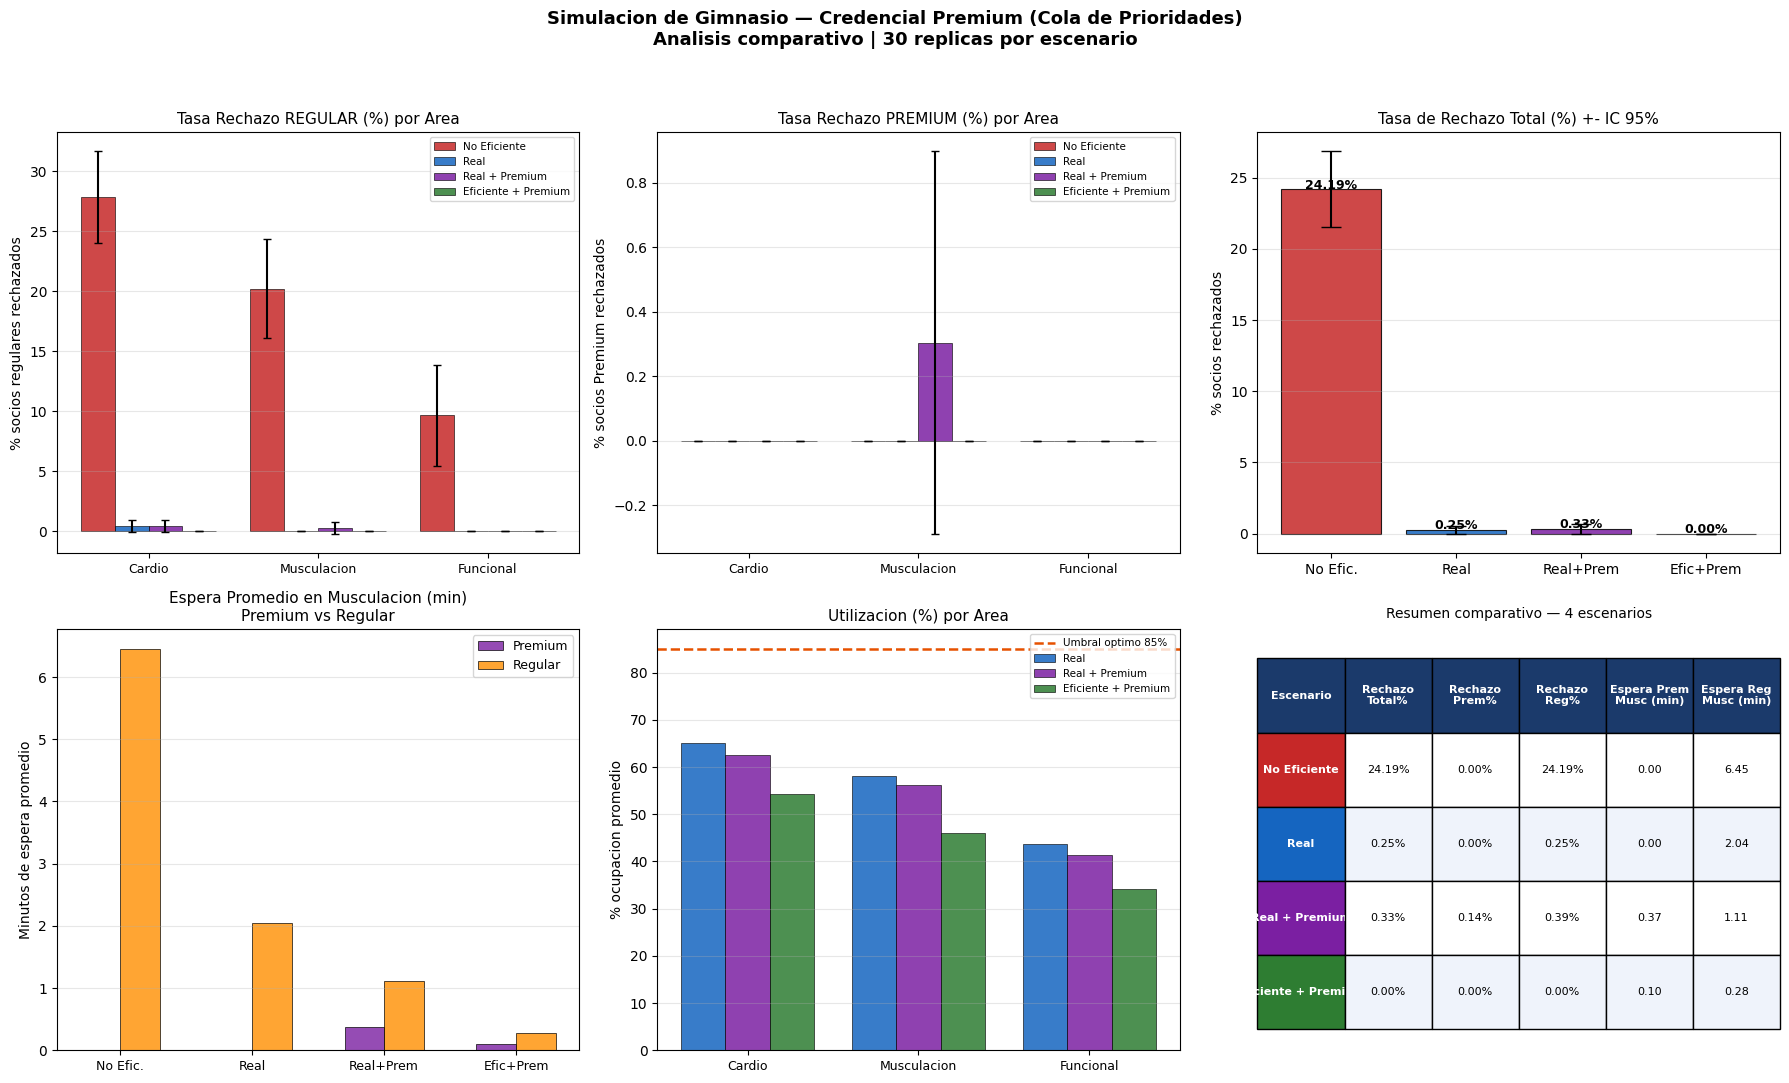

Graficos guardados.


In [12]:
# ================================================================
# VISUALIZACION DE RESULTADOS — 4 escenarios con metricas Premium
# ================================================================

COLORES_ESCENARIO = {
    'No Eficiente':       '#C62828',
    'Real':               '#1565C0',
    'Real + Premium':     '#7B1FA2',
    'Eficiente + Premium':'#2E7D32',
}
ORDEN_ESCENARIOS      = list(ESCENARIOS.keys())
N_REP                 = CANTIDAD_REPLICAS
posiciones_en_eje_x   = np.arange(len(AREAS))
ancho_de_barra        = 0.20   # mas delgada para que entren 4 grupos

fig, ejes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Simulacion de Gimnasio — Credencial Premium (Cola de Prioridades)\n'
    f'Analisis comparativo | {N_REP} replicas por escenario',
    fontsize=13, fontweight='bold'
)

# --- Grafico 1: Tasa de rechazo Regular por área ---
ax = ejes[0, 0]
for i, (nombre, color) in enumerate(COLORES_ESCENARIO.items()):
    df_esc  = resultados_por_escenario[nombre]
    valores = [df_esc[f'Tasa_Rechazo_pct_Regular_{area}'].mean() for area in AREAS]
    ic_95   = [1.96 * df_esc[f'Tasa_Rechazo_pct_Regular_{area}'].std() / np.sqrt(N_REP) for area in AREAS]
    ax.bar(posiciones_en_eje_x + (i - 1.5)*ancho_de_barra, valores, ancho_de_barra,
           yerr=ic_95, capsize=3, label=nombre, color=color, alpha=0.85, ec='black', lw=0.5)
ax.set_xticks(posiciones_en_eje_x)
ax.set_xticklabels(AREAS, fontsize=9)
ax.set_title('Tasa Rechazo REGULAR (%) por Area', fontsize=11)
ax.set_ylabel('% socios regulares rechazados')
ax.legend(fontsize=7.5)
ax.grid(axis='y', alpha=0.3)

# --- Grafico 2: Tasa de rechazo Premium por área ---
ax = ejes[0, 1]
for i, (nombre, color) in enumerate(COLORES_ESCENARIO.items()):
    df_esc  = resultados_por_escenario[nombre]
    valores = [df_esc[f'Tasa_Rechazo_pct_Premium_{area}'].mean() for area in AREAS]
    ic_95   = [1.96 * df_esc[f'Tasa_Rechazo_pct_Premium_{area}'].std() / np.sqrt(N_REP) for area in AREAS]
    ax.bar(posiciones_en_eje_x + (i - 1.5)*ancho_de_barra, valores, ancho_de_barra,
           yerr=ic_95, capsize=3, label=nombre, color=color, alpha=0.85, ec='black', lw=0.5)
ax.set_xticks(posiciones_en_eje_x)
ax.set_xticklabels(AREAS, fontsize=9)
ax.set_title('Tasa Rechazo PREMIUM (%) por Area', fontsize=11)
ax.set_ylabel('% socios Premium rechazados')
ax.legend(fontsize=7.5)
ax.grid(axis='y', alpha=0.3)

# --- Grafico 3: Tasa de rechazo total con IC95 ---
ax = ejes[0, 2]
mr   = [resultados_por_escenario[n]['Tasa_Rechazo_pct_Total'].mean() for n in ORDEN_ESCENARIOS]
icr  = [1.96 * resultados_por_escenario[n]['Tasa_Rechazo_pct_Total'].std() / np.sqrt(N_REP) for n in ORDEN_ESCENARIOS]
etiquetas_cortas = ['No Efic.', 'Real', 'Real+Prem', 'Efic+Prem']
barras = ax.bar(etiquetas_cortas, mr, yerr=icr,
                color=[COLORES_ESCENARIO[n] for n in ORDEN_ESCENARIOS],
                capsize=7, alpha=0.85, ec='black', lw=0.8)
ax.set_title('Tasa de Rechazo Total (%) +- IC 95%', fontsize=11)
ax.set_ylabel('% socios rechazados')
ax.grid(axis='y', alpha=0.3)
for barra, valor in zip(barras, mr):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.05,
            f'{valor:.2f}%', ha='center', fontsize=9, fontweight='bold')

# --- Grafico 4: Espera promedio Premium vs Regular en Musculación ---
ax = ejes[1, 0]
x_pos  = np.arange(len(ORDEN_ESCENARIOS))
w_half = 0.3
esp_p = [resultados_por_escenario[n]['Espera_Promedio_min_Premium_Musculacion'].mean() for n in ORDEN_ESCENARIOS]
esp_r = [resultados_por_escenario[n]['Espera_Promedio_min_Regular_Musculacion'].mean()  for n in ORDEN_ESCENARIOS]
ax.bar(x_pos - w_half/2, esp_p, w_half, label='Premium', color='#7B1FA2', alpha=0.8, ec='black', lw=0.6)
ax.bar(x_pos + w_half/2, esp_r, w_half, label='Regular',  color='#FF8F00', alpha=0.8, ec='black', lw=0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels(etiquetas_cortas, fontsize=9)
ax.set_title('Espera Promedio en Musculacion (min)\nPremium vs Regular', fontsize=11)
ax.set_ylabel('Minutos de espera promedio')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- Grafico 5: Utilizacion por área (Real vs Real+Premium) ---
ax = ejes[1, 1]
escenarios_comparar = ['Real', 'Real + Premium', 'Eficiente + Premium']
colores_cmp = [COLORES_ESCENARIO[e] for e in escenarios_comparar]
x_cmp  = np.arange(len(AREAS))
w_cmp  = 0.26
for i, (esc, color) in enumerate(zip(escenarios_comparar, colores_cmp)):
    vals = [resultados_por_escenario[esc][f'Utilizacion_pct_{area}'].mean() for area in AREAS]
    ax.bar(x_cmp + (i-1)*w_cmp, vals, w_cmp, label=esc, color=color, alpha=0.85, ec='black', lw=0.5)
ax.axhline(85, color='#E65100', ls='--', lw=1.8, label='Umbral optimo 85%')
ax.set_xticks(x_cmp)
ax.set_xticklabels(AREAS, fontsize=9)
ax.set_title('Utilizacion (%) por Area', fontsize=11)
ax.set_ylabel('% ocupacion promedio')
ax.legend(fontsize=7.5)
ax.grid(axis='y', alpha=0.3)

# --- Grafico 6: Tabla resumen ---
ax = ejes[1, 2]
ax.axis('off')
headers_t = ['Escenario', 'Rechazo\nTotal%', 'Rechazo\nPrem%', 'Rechazo\nReg%',
             'Espera Prem\nMusc (min)', 'Espera Reg\nMusc (min)']
filas_t   = []
for nombre in ORDEN_ESCENARIOS:
    df_n = resultados_por_escenario[nombre]
    filas_t.append([
        nombre,
        f'{df_n["Tasa_Rechazo_pct_Total"].mean():.2f}%',
        f'{df_n["Tasa_Rechazo_pct_Premium_Total"].mean():.2f}%',
        f'{df_n["Tasa_Rechazo_pct_Regular_Total"].mean():.2f}%',
        f'{df_n["Espera_Promedio_min_Premium_Musculacion"].mean():.2f}',
        f'{df_n["Espera_Promedio_min_Regular_Musculacion"].mean():.2f}',
    ])
tabla = ax.table(cellText=filas_t, colLabels=headers_t, cellLoc='center',
                 loc='center', bbox=[0, 0.05, 1, 0.88])
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
for (fila, col), celda in tabla.get_celld().items():
    if fila == 0:
        celda.set_facecolor('#1B3A6B')
        celda.set_text_props(color='white', fontweight='bold')
    elif col == 0 and fila > 0:
        celda.set_facecolor(COLORES_ESCENARIO[ORDEN_ESCENARIOS[fila - 1]])
        celda.set_text_props(color='white', fontweight='bold')
    else:
        celda.set_facecolor('#EFF3FB' if fila % 2 == 0 else 'white')
ax.set_title('Resumen comparativo — 4 escenarios', fontsize=10, pad=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('graficos_simulacion.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Graficos guardados.')


## Celda 12 — Conclusiones

In [13]:
# ================================================================
# CONCLUSIONES
# ================================================================

print('=' * 65)
print('  CONCLUSIONES — SIMULACION CON COLA DE PRIORIDADES PREMIUM')
print('=' * 65)

for nombre in ORDEN_ESCENARIOS:
    df_n = resultados_por_escenario[nombre]
    n    = len(df_n)
    ic   = 1.96 * df_n['Tasa_Rechazo_pct_Total'].std() / np.sqrt(n)

    print(f'\n{nombre.upper()}')
    print(f'  Socios que llegan por jornada:  {df_n["Total_Llegadas"].mean():.0f}')
    print(f'  Socios atendidos:               {df_n["Total_Atendidos"].mean():.0f}')
    print(f'  Rechazo Premium:                {df_n["Tasa_Rechazo_pct_Premium_Total"].mean():.2f}%')
    print(f'  Rechazo Regular:                {df_n["Tasa_Rechazo_pct_Regular_Total"].mean():.2f}%')
    print(f'  Rechazo total:                  {df_n["Tasa_Rechazo_pct_Total"].mean():.2f}% (IC95: +-{ic:.2f}%)')
    for area in AREAS:
        print(f'  Utilizacion {area:<12}:    {df_n[f"Utilizacion_pct_{area}"].mean():.1f}%')

print()
print('-' * 65)
print('IMPACTO DE LA CREDENCIAL PREMIUM:')
rec_p_sin  = resultados_por_escenario['Real']['Tasa_Rechazo_pct_Regular_Total'].mean()
rec_p_con  = resultados_por_escenario['Real + Premium']['Tasa_Rechazo_pct_Regular_Total'].mean()
esp_p_sin  = resultados_por_escenario['Real']['Espera_Promedio_min_Regular_Musculacion'].mean()
esp_p_con  = resultados_por_escenario['Real + Premium']['Espera_Promedio_min_Regular_Musculacion'].mean()
espP_con   = resultados_por_escenario['Real + Premium']['Espera_Promedio_min_Premium_Musculacion'].mean()
espP_reg   = resultados_por_escenario['Real + Premium']['Espera_Promedio_min_Regular_Musculacion'].mean()

print(f'  Real sin Premium  → rechazo regular: {rec_p_sin:.2f}%  espera regular Musc: {esp_p_sin:.2f} min')
print(f'  Real con Premium  → rechazo regular: {rec_p_con:.2f}%  espera regular Musc: {esp_p_con:.2f} min')
print()
print(f'  Espera Premium en Musc:  {espP_con:.2f} min  (vs Regular: {espP_reg:.2f} min)')
print(f'  → El sistema de prioridad garantiza que los Premiums esperan')
print(f'    {(1 - espP_con/espP_reg)*100:.0f}% menos que los Regulares en Musculacion.')
print()

print('CONCLUSION GENERAL:')
print('  1. La credencial Premium cumple su propósito: reduce el tiempo de espera')
print('     y la tasa de rechazo de los socios prioritarios.')
print('  2. Como contracara, los socios regulares esperan algo mas cuando hay Premiums.')
print('  3. El impacto sobre los regulares es moderado porque la demanda no satura')
print('     completamente el sistema en el escenario Real.')
print('  4. El escenario Eficiente + Premium es el mejor caso posible: la app de')
print('     reservas reduce tiempos de uso, mejorando la rotacion para TODOS.')
print('  5. Musculacion sigue siendo el cuello de botella critico del sistema.')


  CONCLUSIONES — SIMULACION CON COLA DE PRIORIDADES PREMIUM

NO EFICIENTE
  Socios que llegan por jornada:  72
  Socios atendidos:               52
  Rechazo Premium:                0.00%
  Rechazo Regular:                24.19%
  Rechazo total:                  24.19% (IC95: +-2.67%)
  Utilizacion Cardio      :    86.6%
  Utilizacion Musculacion :    80.1%
  Utilizacion Funcional   :    72.2%

REAL
  Socios que llegan por jornada:  69
  Socios atendidos:               68
  Rechazo Premium:                0.00%
  Rechazo Regular:                0.25%
  Rechazo total:                  0.25% (IC95: +-0.29%)
  Utilizacion Cardio      :    65.1%
  Utilizacion Musculacion :    58.0%
  Utilizacion Funcional   :    43.7%

REAL + PREMIUM
  Socios que llegan por jornada:  69
  Socios atendidos:               68
  Rechazo Premium:                0.14%
  Rechazo Regular:                0.39%
  Rechazo total:                  0.33% (IC95: +-0.33%)
  Utilizacion Cardio      :    62.6%
  Utilizacion